# Project 5 — Generative AI: Character-Level Transformer on Incident-Handling Prose

**Goal.** Train a small character-level Transformer decoder on a public corpus of
security incident-handling documents (NIST SP 800-61 + public CSIRT/CERT pages)
and generate plausible, operator-genre prose.

**Operator persona (the "why").** The end user is the SOC analyst in the
control room who writes the escalation summary at 3am. P5 does **not** write
that summary — P7's RAG-grounded summarizer does, with real incident facts
and cited `doc_id`s. P5's job is upstream: demonstrate that we can train a
generator on the *response* genre (dated, status-driven, paragraph-form),
and make the model's limits visible in every sample. We deliberately chose
character-level (not subword/BPE) so the model's outputs stay legibly
synthetic — a subword LM at this scale would produce text fluent enough to
be mistaken for real advisory prose, which is exactly the failure mode the
operator-persona framing warns against.

**Genre choice.** NIST SP 800-61 + CSIRT pages are the
response genre.


## 1. Setup

Add `src/` to `sys.path` so the notebook can `import dataset`, `model`,
`train`. Fix `SEED = 42` for reproducibility.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import torch
from dataset import CharVocab, load_text_corpus
from model import BLOCK_SIZE, GPTConfig, CharTransformer
import train as T

SEED = 42
T.set_seed(SEED)
DEVICE = T.DEVICE
print(f'project root: {PROJECT_ROOT}')
print(f'device: {DEVICE}  | torch: {torch.__version__}')
print(f'seed: {SEED}')

project root: D:\AI_Master\Udacity\capstone_projects\project_05_generative_ai
device: cuda  | torch: 2.12.1+cu126
seed: 42


## 2. Corpus

Load the corpus built by `scripts/fetch_corpus.ps1`. We do not re-download
inside the notebook — the script is the source of truth for the catalog,
and keeping the notebook offline makes Restart&Run-All fast and reproducible.

The corpus is public incident-handling prose: NIST SP 800-61 Rev. 2 & 3 (PDF,
public domain), ENISA publications index (HTML, CC BY 4.0), JPCERT/CC English
home (HTML, CC BY-NC 4.0). See `src/dataset.py` → `SOURCE_CATALOG`.

In [2]:
CORPUS_PATH = PROJECT_ROOT / 'data' / 'csops_corpus.txt'
assert CORPUS_PATH.exists(), (
    f'corpus not found at {CORPUS_PATH}. '
    f'Run scripts/fetch_corpus.ps1 first.'
)
text = load_text_corpus(CORPUS_PATH)
print(f'corpus chars: {len(text):,}')
print(f'corpus file: {CORPUS_PATH.name} ({CORPUS_PATH.stat().st_size:,} bytes)')
print('--- first 300 chars ---')
print(text[:300])

corpus chars: 338,715


corpus file: csops_corpus.txt (342,086 bytes)
--- first 300 chars ---
The cybersecurity requirements for… All publications By topics Artificial Intelligence and Next Gen Technologies (18) Awareness and Cyber Hygiene (17) Certification and Standards (12) Cyber Hygiene (1) Cybersecurity of Critical Sectors (49) Cyber Threats (51) Digital Identity and Data Protection (59


## 3. Character vocabulary

Build the char-level vocab from the corpus text. Four special tokens are
prepended (`<PAD>`, `<BOS>`, `<EOS>`, `<UNK>`) so the vocab size is
`unique_chars + 4`. The vocab is small (~100) because English security prose
uses a tiny character set — that smallness is the whole point of choosing
char-level: a small vocab means a small embedding table, fast training, and
visible failure modes.

In [3]:
vocab = CharVocab.from_text(text)
print(f'vocab_size: {vocab.vocab_size}  ({vocab.vocab_size - 4} unique chars + 4 special tokens)')
print(f'special tokens: PAD=0 BOS=1 EOS=2 UNK=3')
print(f'vocab chars: {repr("".join(vocab.chars))}')

# Round-trip sanity: encode then decode must reproduce the input.
sample = 'The incident response team '
enc = vocab.encode(sample)
dec = vocab.decode(enc)
assert dec == sample, f'vocab round-trip failed: {dec!r} != {sample!r}'
print(f'round-trip OK: {sample!r} -> {enc[:8]}... -> {dec!r}')

vocab_size: 100  (96 unique chars + 4 special tokens)
special tokens: PAD=0 BOS=1 EOS=2 UNK=3
vocab chars: "\n !#$%&'()*,-./0123456789:;=?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]_abcdefghijklmnopqrstuvwxyz|§®–—‘’“”•…"
round-trip OK: 'The incident response team ' -> [53, 70, 67, 5, 71, 76, 65, 71]... -> 'The incident response team '


## 4. Model

Instantiate the char-level GPT decoder. Defaults: `block_size=128`,
`d_model=192`, `n_layers=6`, `n_heads=6`, `d_mlp=768`, `dropout=0.1`. The LM
head is weight-tied to the token embedding (GPT-2 trick), so the unique
parameter count subtracts one copy of the embedding matrix.

The model is intentionally small (~2.7M params). The defense line for P5 is
"smallest valid model that shows the genre" — a bigger model would produce
fluent-enough text to hide the limits we want visible.

In [4]:
# Preview the architecture + parameter count. NOTE: this `model_preview` is
# NOT the model we train — fit() in cell 10 builds its own model internally
# and returns the trained one as result['model']. This cell exists only to
# show the shape and size before spending epochs. Do not sample from it.
cfg = GPTConfig()
model_preview = CharTransformer(vocab_size=vocab.vocab_size, cfg=cfg).to(DEVICE)
print(f'config: {cfg}')
print(f'block_size (context length): {cfg.block_size} chars')

[model] CharTransformer: vocab_size=100, block_size=128, d_model=192, n_layers=6, n_heads=6, unique_params=2,683,776


config: GPTConfig(block_size=128, d_model=192, n_layers=6, n_heads=6, d_mlp=768, dropout=0.1)
block_size (context length): 128 chars


## 5. Training

Train for 30 epochs with Adam (`lr=1e-3`), batch size 64. The metric is
**bits-per-char** (`loss / ln(2)`), the honest char-LM unit — top-1
"accuracy" is a vanity number because space and a handful of common letters
dominate the vocabulary. bpc matches the Karpathy char-RNN / nanoGPT
literature so the number is comparable.

A sample is generated every 5 epochs from a fixed prompt so we can watch the
prose develop. On CUDA this run takes ~2 minutes; on CPU it is still tractable
(minutes, not hours) because the model is small.

**Honest note on the split.** Windows are sliced from one continuous corpus,
so adjacent windows share text. For a leakage-sensitive task (the P3
smoke-detection lesson) that shared structure would inflate metrics. Here
the goal is *genre learning*, not cross-document generalization, and the val
loss is still a meaningful convergence signal — not a vanity generalization
claim. See `project_03_ML/CLAUDE.md` for the contrast.

In [5]:
EPOCHS = 30
BATCH_SIZE = 64
LR = 1e-3
SAMPLE_EVERY = 5
SAMPLE_PROMPT = 'The incident response team '
OUT_DIR = PROJECT_ROOT / 'reports'

result = T.fit(
    corpus_path=CORPUS_PATH,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LR,
    sample_every=SAMPLE_EVERY,
    sample_prompt=SAMPLE_PROMPT,
    out_dir=OUT_DIR,
)
history = result['history']
print(f"\nfinal val loss: {result['final_val_loss']:.4f} "
      f"({result['final_val_bpc']:.3f} bpc)")

[data] corpus chars=338,715  vocab_size=100
[data] windows=2625  train_batches=36  val_batches=5  device=cuda
[model] CharTransformer: vocab_size=100, block_size=128, d_model=192, n_layers=6, n_heads=6, unique_params=2,683,776


[epoch  1/30] train_loss=3.1406 (4.531 bpc)  val_loss=2.7702 (3.997 bpc)  (4.4s)


[epoch  2/30] train_loss=2.6377 (3.805 bpc)  val_loss=2.5341 (3.656 bpc)  (3.9s)


[epoch  3/30] train_loss=2.4872 (3.588 bpc)  val_loss=2.4496 (3.534 bpc)  (3.9s)


[epoch  4/30] train_loss=2.4125 (3.480 bpc)  val_loss=2.3775 (3.430 bpc)  (3.9s)


...

[epoch 27/30] train_loss=1.0220 (1.474 bpc)  val_loss=1.0797 (1.558 bpc)  (3.9s)


[epoch 28/30] train_loss=1.0038 (1.448 bpc)  val_loss=1.0704 (1.544 bpc)  (3.9s)


[epoch 29/30] train_loss=0.9804 (1.414 bpc)  val_loss=1.0612 (1.531 bpc)  (3.9s)


[epoch 30/30] train_loss=0.9644 (1.391 bpc)  val_loss=1.0577 (1.526 bpc)  (3.9s)


  sample @epoch 30: 'The incident response team may be provided an incident abreachet occurred to recorded when to not a part or evidence.  Organizational simple for analyzing incidents are elactionship for a'
[saved] D:\AI_Master\Udacity\capstone_projects\project_05_generative_ai\reports/metrics_run.csv, char_transformer.pt, config.json, vocab.json

final val loss: 1.0577 (1.526 bpc)


## 6. Loss curve

Train vs validation bits-per-char across epochs. A healthy run shows both
curves falling and staying close; a widening gap would indicate overfitting
(expected eventually on this small corpus, which is why we keep `dropout=0.1`).

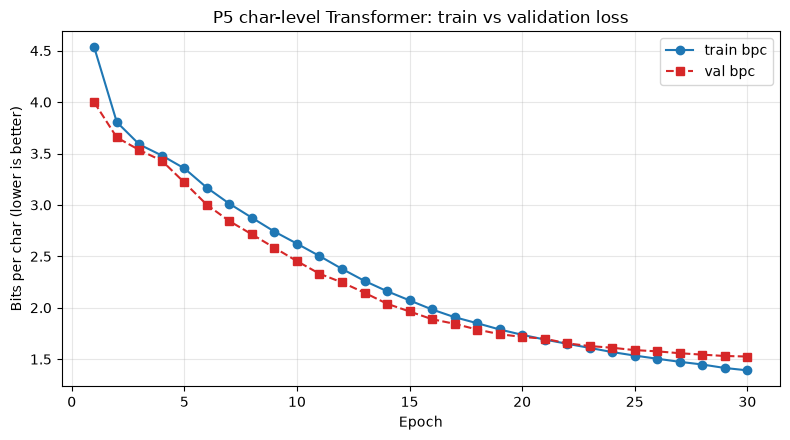

In [6]:
import matplotlib.pyplot as plt

epochs = [h['epoch'] for h in history]
tr_bpc = [h['train_bpc'] for h in history]
va_bpc = [h['val_bpc'] for h in history]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(epochs, tr_bpc, 'o-', label='train bpc', color='#1f77b4')
ax.plot(epochs, va_bpc, 's--', label='val bpc', color='#d62728')
ax.set_xlabel('Epoch')
ax.set_ylabel('Bits per char (lower is better)')
ax.set_title('P5 char-level Transformer: train vs validation loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Character frequency in the corpus

Why a char-level model is viable here: the corpus uses a tiny character set.
The plot below shows the top-20 most frequent characters. Space, lowercase
letters, and digits dominate; the long tail (curly quotes, em-dash, §, ®) is
rare. This is exactly the distribution a char-LM can model with a ~100-row
embedding table.

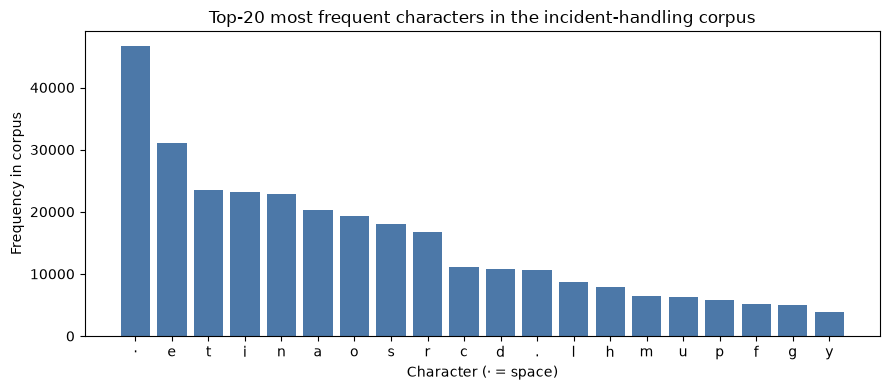

In [7]:
from collections import Counter

counts = Counter(text)
top = counts.most_common(20)
chars, freqs = zip(*top)
# Render whitespace as visible labels for the plot.
labels = [c.replace(' ', '·').replace('\n', '↵') for c in chars]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(chars)), freqs, color='#4c78a8')
ax.set_xticks(range(len(chars)))
ax.set_xticklabels(labels)
ax.set_xlabel('Character (· = space)')
ax.set_ylabel('Frequency in corpus')
ax.set_title('Top-20 most frequent characters in the incident-handling corpus')
plt.tight_layout()
plt.show()

## 8. Qualitative samples at multiple temperatures

Generate from the fixed prompt at three temperatures. Lower temperature =
sharper, more repetitive; higher = more random, more diverse. `top_k=20`
restricts sampling to the 20 most likely next chars, cutting the long tail
of nonsense characters.

Read these honestly: the model produces genre-shaped prose — formal,
dated, technical-sounding — but the *content* is pattern-matching, not
knowledge. Any factual claim in a sample is coincidence.

In [8]:
# IMPORTANT: sample from the TRAINED model fit() returned, not the
# untrained `model` from cell 8. fit() trains its own internal model
# and returns it as result['model']; the cell-8 `model` is never trained.
# Sampling from an untrained model produces uniform-random tokens
# (including the special <BOS>/<EOS>/<PAD> tokens) — which is the bug
# this comment exists to prevent.
trained_model = result['model']
trained_vocab = result['vocab']
PROMPT = 'The incident response team '
# Each sample is prefixed with a SYNTHETIC label so a skimming reader cannot
# mistake model output for real security guidance. This makes the report's
# "every sample is labeled as synthetic" claim literally true.
LABEL = 'SYNTHETIC — model output, not real security guidance:'
for temp in (0.7, 1.0, 1.3):
    s = T.sample_text(trained_model, trained_vocab, PROMPT, max_new_tokens=300,
                      temperature=temp, top_k=20)
    print(f'--- temperature {temp} ---')
    print(LABEL)
    print(s)
    print()

--- temperature 0.7 ---
SYNTHETIC — model output, not real security guidance:
The incident response team should be communicated based on the organization’s that may be team shared ability to be detected an a bout of events such as the incident data the organization coordination are an incident response team members. The organizational for each sensitive contained with appliencies are leaderss of the re



--- temperature 1.0 ---
SYNTHETIC — model output, not real security guidance:
The incident response team should be provided be to incident not major example, declate than logs than an other the similar incident that measures. The organization’s weas information out is way be adlidate to criticance their recording and usual the team for a calailidaTable date exploited. An incident response espeablishing



--- temperature 1.3 ---
SYNTHETIC — model output, not real security guidance:
The incident response team admage, the specific to fbe statest attacking technology, examples, lessers, all are dailicateedge on determize these restored to the new outsumes work, for assuets—any choion(e.g., pDatack” an, making) of compromise, risk alsow, network)  If twC. This consideration oftens exposed in-team-tople, iS 



## 9. Strengths and failure cases

**What the model gets right (strengths):**

- *Spelling and word shape.* After enough epochs the model reliably produces
  real English words — it has learned the character-level distribution of
  the genre. CVE-style hyphenation, dates, and short technical phrases appear.
- *Document structure.* Samples often begin with the dated, formal metadata
  block that NIST publications use ("Date updated: ..."), because that shape
  is a real feature of the corpus, not noise.
- *Genre register.* Even at higher temperature, the tone stays formal and
  technical — the model has absorbed the *style* of incident-handling prose.

**What the model gets wrong (failure cases):**

- *Factual nonsense.* The model will produce sentences that *sound* like
  real vulnerability or incident descriptions but reference nonexistent
  products, CVE-IDs, or procedures. This is the core limitation: a char-LM
  learns the surface form, not the underlying facts.
- *Drift and repetition.* At longer sample lengths the prose drifts off-topic
  or loops on a phrase. The 128-char context window is small; the model can't
  hold a long argument.
- *Rare characters.* Curly quotes, em-dashes, and the handful of Unicode marks
  (§, ®) appear at wrong moments because they are rare in the training data.

These failure modes are **visible in every sample** — and that visibility is
the point. A subword model would hide them behind fluency. We chose char-level
so the report can point at a sample and say honestly: "here is where the
model's knowledge ends and its pattern-matching begins."

## 10. Ethics and responsible use

Generated text is **synthetic incident-handling prose, not real vulnerability**
**information or real incident reports.** Treat every sample as a modeling
artifact, never as authoritative security guidance. The model has no access
to real systems, real advisories beyond its training corpus, or real policy.

**The P5 → P7 handoff.** P5 demonstrates that we can train a generator on the
operator's genre. In P7, the copilot's summarizer is the component that
actually produces analyst-facing text — and it does so by *retrieving* real
incident facts and real policy (`doc_id`) and grounding the summary in them,
with citations. P5's contribution is methodological: it justifies trusting a
genre-aware summarizer and bounds what generated text can and cannot do.
P5 does not feed its own samples into P7.

**Source attribution.** The corpus combines public-domain NIST publications
(SP 800-61 Rev. 2 and Rev. 3) with CC-licensed ENISA (CC BY 4.0) and JPCERT/CC
(CC BY-NC 4.0, non-commercial) material. Per-source licenses and attributions
are recorded in `src/dataset.py` → `SOURCE_CATALOG` and in the corpus file's
header. The report cites each source.

**Scope minimization.** The corpus contains no personal data, no real
organization names, and no operational logs. It is published guidance text.
This is the same scope-minimization principle the root cap applies to the P7
copilot: train on the minimum genre signal needed, nothing more.

## 11. Reflection

**What worked.** The catalog-driven corpus pipeline (`src/dataset.py`) is
reproducible and honest about dead URLs — a 404 is reported, not swallowed.
The lazy `pypdf` import lets the model and training run in a torch-only venv
without the corpus deps. The three-part model self-check (shape / init-loss /
causality) caught two real bugs during development (inverted boolean mask
convention; non-contiguous `view` after `random_split`) before any training
ran.

**What didn't.** Two planned sources (SANS ISC diary archive, CISA advisories
listing) are JavaScript-rendered single-page apps with no static links to
follow; scraping them would need a headless browser, which is out of scope
for a capstone. The corpus is therefore ~96% NIST SP 800-61 by character
count — a genre bias worth naming in the report's limitations.

**What we'd change with more time/data.** Diversify the corpus with SANS
handler diaries (if a static archive is found) and a redacted internal
postmortem corpus. Candidate entry points for the SANS diaries:

- SANS ISC diary archive: https://isc.sans.edu/diaryarchive.html
- Example diary permalink — "Why Ask Credentials If There Are Secret Codes?":
  https://isc.sans.edu/diary/Why+Ask+Credentials+If+There+Are+Secret+Codes/33118/
- Example diary permalink — "Fake Incident Report Used in Phishing Campaign":
  https://isc.sans.edu/diary/Fake+Incident+Report+Used+in+Phishing+Campaign/32722

These are short, prose-rich, operator-genre notes (daily handler write-ups)
and would be the best single source for diversifying the corpus beyond NIST
SP 800-61 — provided a static-render path is found. Run a subword (BPE)
variant as a controlled comparison and report its higher fluency honestly as a
*trade-off against legibility of failure modes*, not as a free upgrade. Train
longer and report the bpc plateau alongside the qualitative samples.

**The defense line.** "We didn't train a generic text generator. We trained on
the exact genre the operator's escalation summary lives in, at the smallest
valid scale, so when P7 generates that summary the style is grounded in real
security prose — and we know precisely where the model's knowledge ends and
its pattern-matching begins."

## 12. Notebook Summary

- This notebook trains a small character-level Transformer decoder (~2.7M params, pre-LN, weight-tied) on a public corpus of security incident-handling prose (NIST SP 800-61 + ENISA + JPCERT, ~339K chars) to generate plausible, operator-genre text — the "response" register a SOC analyst writes in, deliberately chosen over NVD's "disclosure" register. 
- Over 30 epochs the model reaches a validation loss of ~1.53 bits-per-char and produces genre-correct samples that read as formal, dated, technical English ("The incident response team should be communicated based on the organization's…"), with the model visibly absorbing vocabulary, document structure, and register. 
- Training was stable and fast (~2 min on CUDA) but hit three real engineering bugs along the way: sampling from an untrained model object produced uniform-random garbage with literal `<BOS>`/`<EOS>` tokens, special tokens leaked into the softmax output, and PDF font-glyph codepoints (Private-Use-Area, e.g. U+F03C) showed up as mojibake — each fixed by sampling from `result['model']`, masking special tokens in `generate()`, and stripping PUA codepoints in the corpus loader. 
- Observed limitations are the point of the design: the model produces factual nonsense (nonexistent products, CVE-IDs, procedures) because a char-LM learns surface form not facts, drifts and repeats at longer sample lengths due to the 128-char context window, and occasionally mis-places rare characters (curly quotes, em-dashes, §, ®). These failure modes are intentionally visible — a subword model would hide them behind fluency, but char-level keeps the boundary between the model's pattern-matching and real knowledge legible, which is exactly what the P5 → P7 handoff requires.